# Global bound in the scattered-voltage basis with all material in the background

Same bound as `VscatBound.ipynb` (scattered voltage as the optimization variable), but with all material moved to the background
as in `antenna_limits_background.ipynb` and main.tex, Sec. *Moving Material to the Background*. The background is the full plate,
and the design removes material: in the admittance picture the background conductance $Z_\mathrm{s}^{-1}$ is changed by
$\Delta y_i \in \{0, -Z_\mathrm{s}^{-1}\}$, i.e. a removed basis function carries the gain (negative) design impedance
$$Z_\mathrm{d} = Z_\rho - 2 Z_\mathrm{a} = -Z_\mathrm{s}, \qquad Z_\mathrm{a} = Z_\rho = Z_\mathrm{s}\mathbf 1 .$$

The design current is the change of current due to the removal, $\Delta I = I - Z_\mathrm{s}^{-1} E$, with total voltage
$E = V - Z_0 I$. Eliminating $I$ from $E$ gives the system of main.tex,
$$(Z_\mathrm{d} + Z_\mathrm{b})\, \Delta I = Z_\mathrm{b} I_0, \qquad I_0 = Z_0^{-1} V,$$
where the background impedance is the **parallel** combination (admittances add)
$$Z_\mathrm{b} = \left(Z_0^{-1} + Z_\mathrm{a}^{-1}\right)^{-1} = Z_\mathrm{a} Z_\mathrm{tot}^{-1} Z_0 ,$$
and $E_\mathrm{b} = Z_\mathrm{b} I_0 = Z_\mathrm{s} I_\mathrm{full}$ is the total voltage on the full plate. The series form
$Z_\mathrm{b} = Z_0 + Z_\mathrm{a}$ does not satisfy this system (checked below).

The scattered voltage relative to the background, $V_\mathrm{sca} = -Z_\mathrm{b}\Delta I$, gives $E = E_\mathrm{b} + V_\mathrm{sca}$, and
$V_\mathrm{sca} = 0$ is the full plate. The pointwise relation
$\Delta I_i^*\left(E_{\mathrm b,i} + V_{\mathrm{sca},i} - Z_\mathrm{d}\, \Delta I_i\right) = 0$ holds for any structure
($\Delta I_i = 0$ on material, $Z_\mathrm{d} \Delta I_i = E_i$ on removed basis functions), so the derivation of `VscatBound.ipynb`
applies with $Z_0 \to Z_\mathrm{b}$, $Z_\mathrm{s} \to Z_\mathrm{d}$, $V \to E_\mathrm{b}$ and $I \to \Delta I = -W V_\mathrm{sca}$,
$W = Z_\mathrm{b}^{-1}$.

In [1]:
import numpy as np
import scipy.sparse as sp
import time
from dolphindes.cvxopt import DenseSharedProjQCQP, OptimizationHyperparameters

In [2]:
# Physical constants
epsilon_0 = 8.854e-12 # F/m
mu_0 = 4e-7 * np.pi # H/m
c = 1/np.sqrt(epsilon_0 * mu_0) # speed of light in vacuum

E0 = 1e3 # plane wave amplitude in V/m

frequency = 2.45e9 # frequency in Hz
wavelength = c / frequency # wavelength in m
print(f"Wavelength: {wavelength} m")

ka = 1 # electrical size of the antenna
k = 2 * np.pi / wavelength # wavenumber
a = ka / k # antenna circumradius
print(f"Antenna circumradius: {a} m")

omega = 2 * np.pi * frequency # angular frequency

conductivity_reduction_factor = 1 # factor to reduce conductivity for testing purposes
copper_conductivity = conductivity_reduction_factor*5.96e7 # S/m
copper_permittivity = 1 + 1j * copper_conductivity / (omega * epsilon_0) # copper permittivity in dimensionless units
print(f"Copper permittivity: {copper_permittivity:.2e}")

Wavelength: 0.1223655664053944 m
Antenna circumradius: 0.019475084757658086 m
Copper permittivity: 1.00e+00+4.37e+08j


In [3]:
# Calculate surface impedance
delta = np.sqrt(2 / (omega * mu_0 * copper_conductivity)) # skin depth in m
Zs = (1 + 1j) / (copper_conductivity * delta)
print(f"Surface impedance: {Zs} Ω")

# Load matrices from text files
Lmat = np.loadtxt(r"Lmat_dipole.txt", delimiter=',') # lossy matrix

Ndes = Lmat.shape[0] # number of design variables
print("Number of design variables: ", Ndes)

Lchol = np.linalg.cholesky(Lmat).conj().T
LcholInv = np.linalg.inv(Lchol)

def Msym(M):
    return(0.5*(M.conj().T + M))

def Mchol(M):
    return(Msym(LcholInv.conj().T @ M @ LcholInv))

R0 = np.loadtxt(r"R0_dipole.txt", delimiter=',') # radiated power matrix
R0 = Mchol(R0)

X0 = np.loadtxt(r"X0_dipole.txt", delimiter=',') # reactive power matrix
X0 = Mchol(X0)

Vinc = np.loadtxt(r"V_dipole.txt", delimiter=',') # voltage excitation vector
Vinc = E0*Vinc
def Vchol(v):
    return(LcholInv.conj().T @ v)
Vinc = Vchol(Vinc)

Zmat = Zs * np.eye(Ndes) # material impedance matrix
Z0 = R0 + 1j*X0 # free-space impedance matrix
Ztot = Z0 + Zmat # total impedance matrix

def evalObjI(Ivec):
    # radiated power in the current basis
    return(0.5*np.real(Ivec.conj().T @ R0 @ Ivec))

# full plate performance
Ifull = np.linalg.solve(Ztot, Vinc) # current distribution for full plate
Pfull = evalObjI(Ifull) # objective for full plate
print(f"Objective for full plate: {Pfull:.6e} W")

Surface impedance: (0.012739130327240646+0.012739130327240646j) Ω
Number of design variables:  195
Objective for full plate: 1.010821e+01 W


## Material in the background

All material is moved to the background, $Z_\mathrm{a} = Z_\mathrm{s}\mathbf 1$. The background admittance is
$W = Z_\mathrm{b}^{-1} = Z_0^{-1} + Z_\mathrm{a}^{-1}$, the source current $I_0 = Z_0^{-1}V$ and the background voltage
$E_\mathrm{b} = Z_\mathrm{b} I_0$. Checks: $E_\mathrm{b} = Z_\mathrm{s} I_\mathrm{full}$, and the removal of all material
($\Delta I = -V/Z_\mathrm{s}$, $I = 0$) solves $(Z_\mathrm{d} + Z_\mathrm{b})\Delta I = Z_\mathrm{b} I_0$ with the parallel $Z_\mathrm{b}$,
but not with the series $Z_0 + Z_\mathrm{a}$.

In [4]:
Za = Zs * np.eye(Ndes)   # all material moved to the background
Zd = -Zs                 # design impedance Z_rho - 2 Za of the removed material (gain)

W0 = np.linalg.inv(Z0)          # Z0^{-1}
W = W0 + np.linalg.inv(Za)      # background admittance Zb^{-1} = Z0^{-1} + Za^{-1}
WH = W.conj().T
Zb = np.linalg.inv(W)           # background impedance, parallel combination of Z0 and Za
I0 = W0 @ Vinc                  # source current
Eb = Zb @ I0                    # total voltage of the background (full plate)
print(f"cond(Z0) = {np.linalg.cond(Z0):.3e}, cond(Zb) = {np.linalg.cond(Zb):.3e}")
print(f"||Eb - Zs Ifull||/||Eb|| = {np.linalg.norm(Eb - Zs*Ifull)/np.linalg.norm(Eb):.2e}")

dIempty = -Vinc/Zs   # all material removed: I = 0, E = V
for name, Zback in [("parallel Zb", Zb), ("series Z0 + Za", Z0 + Za)]:
    res = np.linalg.norm((Zd*np.eye(Ndes) + Zback) @ dIempty - Zback @ I0)/np.linalg.norm(Zback @ I0)
    print(f"empty structure residual of (Zd + Zb) dI = Zb I0, {name}: {res:.2e}")

cond(Z0) = 1.750e+04, cond(Zb) = 1.011e+00
||Eb - Zs Ifull||/||Eb|| = 1.72e-12
empty structure residual of (Zd + Zb) dI = Zb I0, parallel Zb: 4.59e-14
empty structure residual of (Zd + Zb) dI = Zb I0, series Z0 + Za: 3.24e+04


## Objective in $V_\mathrm{sca}$

The physical current is $I = Z_\mathrm{s}^{-1}E + \Delta I = I_\mathrm{full} - Z_0^{-1}V_\mathrm{sca}$, so the radiated power
$\tfrac12 I^H R_0 I$ takes the dolphindes form $-x^H A_0 x + 2\operatorname{Re}(x^H s_0) + c_0$, $x = V_\mathrm{sca}$, with
$$A_0 = -\tfrac12 Z_0^{-H} R_0 Z_0^{-1},\qquad s_0 = -\tfrac12 Z_0^{-H} R_0 I_\mathrm{full},\qquad c_0 = P_\mathrm{full} .$$
Unlike in `VscatBound.ipynb`, the linear and constant terms do not vanish since $x = 0$ is the full plate.

In [5]:
Obj = -0.5 * Msym(W0.conj().T @ R0 @ W0)
obj = -0.5 * W0.conj().T @ R0 @ Ifull
obj0 = Pfull

def dIfromV(Vsca):
    # design (removal) current
    return(-W @ Vsca)

def VtoI(Vsca):
    # physical current
    return(Ifull - W0 @ Vsca)

def evalObj(Vsca):
    return(-np.real(Vsca.conj().T @ Obj @ Vsca) + 2*np.real(Vsca.conj().T @ obj) + obj0)

def VscaFromI(I):
    # Vsca = -Zb dI with dI = I - E/Zs, E = V - Z0 I
    return(-Zb @ (I - (Vinc - Z0 @ I)/Zs))

# check on a random binary structure: (Zs + diag(rho) Z0) I = diag(rho) V
rng = np.random.default_rng(0)
rhoTest = (rng.random(Ndes) > 0.5).astype(complex)
Itest = np.linalg.solve(Zs*np.eye(Ndes) + np.diag(rhoTest) @ Z0, rhoTest*Vinc)
Vtest = VscaFromI(Itest)
print(f"objective for full plate in Vsca: {evalObj(np.zeros(Ndes)):.6e} W (I basis {Pfull:.6e} W)")
print(f"random structure: objective {evalObj(Vtest):.6e} W (I basis {evalObjI(Itest):.6e} W), "
      f"current recovery {np.linalg.norm(VtoI(Vtest) - Itest)/np.linalg.norm(Itest):.2e}")

objective for full plate in Vsca: 1.010821e+01 W (I basis 1.010821e+01 W)
random structure: objective 3.655418e-07 W (I basis 3.655418e-07 W), current recovery 5.98e-09


## Power conservation in the shared projector form

For a complex diagonal projector $P = \operatorname{diag}(p)$ the constraint
$\operatorname{Re}\left[\Delta I^H P (E_\mathrm{b} + V_\mathrm{sca} - Z_\mathrm{d} \Delta I)\right] = 0$ holds for any structure.
As in `VscatBound.ipynb` it is the shared projector form
$\operatorname{Re}\left(-x^H A_1 P' A_2 x + 2 x^H A_2^H P'^H s_1\right) = 0$ with
$$A_1 = 1 + Z_\mathrm{d}^* W^H,\qquad A_2 = W,\qquad s_1 = -\tfrac12 E_\mathrm{b},\qquad P' = P^H .$$

With $\Delta I = I - Z_\mathrm{s}^{-1}E$ the pointwise relation is
$w'_i = \Delta I_i^*(E_i + Z_\mathrm{s}\Delta I_i) = -\frac{Z_\mathrm{s}}{Z_\mathrm{s}^*}\, w_i^*$, with
$w_i = I_i^*(E_i - Z_\mathrm{s} I_i)$ of the current basis. The global real power constraint
$\operatorname{Re}\sum_i w_i = 0$ is therefore $p = Z_\mathrm{s}/Z_\mathrm{s}^*$ (up to sign), and the reactive one $p = jZ_\mathrm{s}/Z_\mathrm{s}^*$.
The quadratic part of the real power constraint is $Z_0^{-H}\operatorname{Re}(Z_\mathrm{tot}) Z_0^{-1}$, the congruent image of the
$I$-basis real power constraint.

In [6]:
A1 = np.eye(Ndes) + np.conj(Zd) * WH
A2 = W
s1 = -0.5 * Eb

qReal = Zs/np.conj(Zs)
qList = [qReal, 1j*qReal]   # real and reactive power
Plist = [sp.diags(np.conj(q)*np.ones(Ndes, dtype=complex)) for q in qList]   # P' = diag(p^*)

def projRes(x, Pp):
    # Re(-x^H A1 P' A2 x + 2 x^H A2^H P'^H s1)
    return(np.real(-x.conj() @ A1 @ (Pp @ (A2 @ x)) + 2*x.conj() @ (A2.conj().T @ (Pp.conj().T @ s1))))

def directRes(Vsca, p):
    # Re[dI^H diag(p) (Eb + Vsca - Zd dI)] evaluated directly
    dI = dIfromV(Vsca)
    return(np.real(np.sum(p*np.conj(dI)*(Eb + Vsca - Zd*dI))))

ReZtotV = Msym(W0.conj().T @ np.real(Ztot) @ W0)
print(f"real power quadratic part vs Z0^-H Re(Ztot) Z0^-1: "
      f"{np.linalg.norm(Msym(A1 @ Plist[0] @ A2) - ReZtotV)/np.linalg.norm(ReZtotV):.2e}")
print("power conservation residuals at a random structure:",
      [f"{projRes(Vtest, Pp):.2e} (direct {directRes(Vtest, q*np.ones(Ndes)):.2e})" for Pp, q in zip(Plist, qList)])

# check: shared projector form equals the direct constraint for a random projector at a random point
pRand = np.random.randn(Ndes) + 1j*np.random.randn(Ndes)
xRand = np.random.randn(Ndes) + 1j*np.random.randn(Ndes)
print(f"random p, random x: shared form {projRes(xRand, sp.diags(np.conj(pRand))):.6e}, direct {directRes(xRand, pRand):.6e}")

real power quadratic part vs Z0^-H Re(Ztot) Z0^-1: 9.62e-14
power conservation residuals at a random structure: ['3.41e-13 (direct 4.16e-13)', '4.42e-13 (direct 3.96e-13)']
random p, random x: shared form -2.547854e+00, direct -2.547854e+00


## Dual problem

As in `VscatBound.ipynb`, the real power multiplier $\lambda > \tfrac12$ makes
$A = Z_0^{-H}\left(-\tfrac12 R_0 + \lambda \operatorname{Re}Z_\mathrm{tot}\right) Z_0^{-1}$ positive definite.

In [7]:
QCQP = DenseSharedProjQCQP(Obj, obj, obj0, A1, s1, Plist, A2=A2, verbose=1)

lags_init = np.array([1.0, 0.0])   # lambda = 1 on the real power constraint
print(f"initial lags dual feasible: {QCQP.is_dual_feasible(lags_init)}")

opt_params = OptimizationHyperparameters(opttol=1e-6,
    gradConverge=True,
    min_inner_iter=10,
    max_restart=10,
    penalty_ratio=1e-2,
    penalty_reduction=0.1,
    break_iter_period=5,
    verbose=0)

t1 = time.time()
result = QCQP.solve_current_dual_problem(method='newton', init_lags=lags_init, opt_params=opt_params)
print(f"bound: {result[0]:.6e} W, time: {time.time()-t1:.2f}s, Lagrange multipliers: {QCQP.current_lags}")

Precomputed 2 A matrices and Fs vectors.
initial lags dual feasible: True
bound: 1.012093e+01 W, time: 0.06s, Lagrange multipliers: [ 0.98806808 -0.03777126]


In [8]:
lags = QCQP.current_lags
totalA = QCQP._get_total_A(lags)
print(f"minimum eigenvalue of A: {np.min(np.linalg.eigvalsh(Msym(totalA))):.3e}")

Vstar = QCQP.current_xstar
Istar = VtoI(Vstar)
print(f"dual bound {QCQP.current_dual:.6e} W, P(x*) {evalObj(Vstar):.6e} W (I basis {evalObjI(Istar):.6e} W), full plate {Pfull:.6e} W")
print("constraint residuals at x*:", [f"{projRes(Vstar, Pp):.2e}" for Pp in Plist])

minimum eigenvalue of A: 1.813e-06
dual bound 1.012093e+01 W, P(x*) 1.012093e+01 W (I basis 1.012093e+01 W), full plate 1.010821e+01 W
constraint residuals at x*: ['-1.40e-08', '-1.91e-07']


## Reference: global bound in the $I$ basis

Same constraints in the current basis without background (as in `VscatBound.ipynb`). The bounds must agree.

In [9]:
Umat = -1j * Ztot.conj()/np.conj(Zs)   # A1 = U^H with U = j Ztot (Ztot symmetric)
eVec = 1j * Vinc / 2/Zs
Pdiags = np.conj(Zs) * np.column_stack([np.ones(Ndes), 1j*np.ones(Ndes)]).astype(complex)  # global: Im and Re part
PlistI = [sp.diags(Pdiags[:, i]) for i in range(Pdiags.shape[1])]

QCQP_I = DenseSharedProjQCQP(-0.5*R0, np.zeros(Ndes, dtype=complex), 0, Umat, eVec, PlistI, verbose=0)
resultI = QCQP_I.solve_current_dual_problem(method='newton', init_lags=np.array([0.0, 1.0]), opt_params=opt_params)
print(f"I basis bound: {resultI[0]:.6e} W, background Vsca basis bound: {result[0]:.6e} W, relative difference {abs(resultI[0]-result[0])/resultI[0]:.2e}")
print(f"relative difference of x*: {np.linalg.norm(QCQP_I.current_xstar - Istar)/np.linalg.norm(QCQP_I.current_xstar):.2e}")

I basis bound: 1.012093e+01 W, background Vsca basis bound: 1.012093e+01 W, relative difference 1.51e-12
relative difference of x*: 3.42e-08


## Local projector constraints by GCD

The local constraints share $A_1$, $A_2$, $s_1$ with the global ones and are generated by `run_gcd` as in `VscatBound.ipynb`.
The strongest local violation is now
$p'_i = (2s_1 - A_1^H x^\star)_i (A_2 x^\star)_i^*$, i.e. $\Delta I_i^{\star *}\left(E_\mathrm{b} + V^\star_{\mathrm{sca}} - Z_\mathrm{d}\Delta I^\star\right)_i$.
Since $w' = -(Z_\mathrm{s}/Z_\mathrm{s}^*)\,w^*$ pointwise, the local constraints span the same set as in the current basis.

In [10]:
import copy
from dolphindes.cvxopt.gcd import GCDHyperparameters

Ngcd = 20   # number of GCD iterations, each adds a max violation and a min eigenvalue projector

gQCQP = copy.deepcopy(QCQP)
gQCQP.verbose = 0
gcd_params = GCDHyperparameters(max_proj_cstrt_num=2 + 2*Ngcd,
    max_gcd_iter_num=Ngcd,
    gcd_iter_period=Ngcd + 1,   # no early termination
    opt_params=opt_params)

def localViolation(Vsca):
    # pointwise physical w_i = I_i^* (E - Zs I)_i with E = Eb + Vsca, zero for any physical structure
    I = VtoI(Vsca)
    return(np.conj(I)*(Eb + Vsca - Zs*I))

def localViolationBack(Vsca):
    # pointwise w'_i = dI_i^* (Eb + Vsca - Zd dI)_i of the background formulation, |w'| = |w|
    dI = dIfromV(Vsca)
    return(np.conj(dI)*(Eb + Vsca - Zd*dI))

t1 = time.time()
gQCQP.run_gcd(gcd_params)
print(f"bound: {QCQP.current_dual:.6e} -> {gQCQP.current_dual:.6e} W (full plate {Pfull:.6e} W), "
      f"{gQCQP.n_proj_constr} projectors, {time.time()-t1:.2f}s")

At GCD iteration #1, best dual bound found is             10.120932760127257.


min eigenvalue: 1.812902e-06


At GCD iteration #2, best dual bound found is             10.113198452248076.
min eigenvalue: 1.421460e-06


At GCD iteration #3, best dual bound found is             10.113175883292184.
min eigenvalue: 1.420209e-06


At GCD iteration #4, best dual bound found is             10.112937261819528.
min eigenvalue: 1.408314e-06


...

At GCD iteration #17, best dual bound found is             10.109552241626437.
min eigenvalue: 1.200872e-06


At GCD iteration #18, best dual bound found is             10.109461363067018.
min eigenvalue: 1.194141e-06


At GCD iteration #19, best dual bound found is             10.10938732311711.
min eigenvalue: 1.188701e-06


At GCD iteration #20, best dual bound found is             10.109326246876812.
min eigenvalue: 1.184156e-06


At GCD iteration #21, best dual bound found is             10.109273774468143.
bound: 1.012093e+01 -> 1.010927e+01 W (full plate 1.010821e+01 W), 42 projectors, 3.93s


minimum eigenvalue of A: 1.180e-06
dual bound 1.010927e+01 W, P(x*) 1.010927e+01 W
max |constraint residual| at x*: 6.43e-08 (global), 2.88e-05 (all)
||local violation||: global 8.605e-01, GCD 1.400e+00, | |w'| - |w| | 1.34e-13


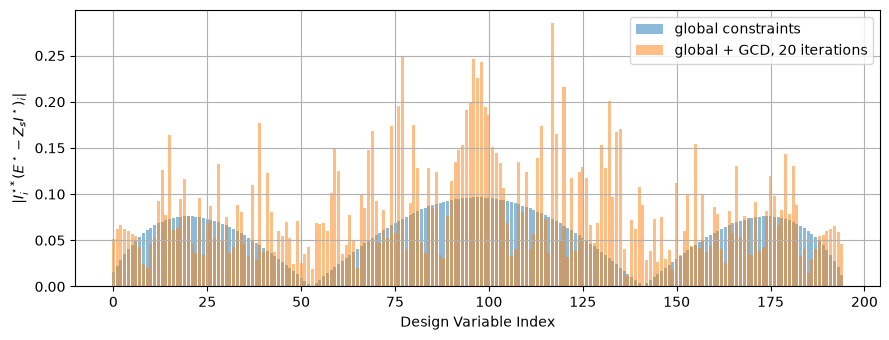

In [11]:
import matplotlib.pyplot as plt

Vstar = gQCQP.current_xstar
print(f"minimum eigenvalue of A: {np.min(np.linalg.eigvalsh(Msym(gQCQP._get_total_A(gQCQP.current_lags)))):.3e}")
print(f"dual bound {gQCQP.current_dual:.6e} W, P(x*) {evalObj(Vstar):.6e} W")
PlistG = gQCQP.Proj.get_Pdata_column_stack()
print(f"max |constraint residual| at x*: {max(abs(projRes(Vstar, Pp)) for Pp in Plist):.2e} (global), "
      f"{max(abs(projRes(Vstar, sp.diags(PlistG[:, j]))) for j in range(PlistG.shape[1])):.2e} (all)")
print(f"||local violation||: global {np.linalg.norm(localViolation(QCQP.current_xstar)):.3e}, "
      f"GCD {np.linalg.norm(localViolation(Vstar)):.3e}, "
      f"| |w'| - |w| | {np.max(np.abs(np.abs(localViolationBack(Vstar)) - np.abs(localViolation(Vstar)))):.2e}")

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.bar(np.arange(Ndes), np.abs(localViolation(QCQP.current_xstar)), alpha=0.5, label='global constraints')
ax.bar(np.arange(Ndes), np.abs(localViolation(Vstar)), alpha=0.5, label=f'global + GCD, {Ngcd} iterations')
ax.set_xlabel('Design Variable Index'); ax.set_ylabel(r'$|I^{\star *}_i(E^\star - Z_s I^\star)_i|$')
ax.legend(); ax.grid(True)
plt.tight_layout(); plt.show()

## Inferred complex material density

With the background, the density follows from the design admittance $\Delta y_i = \Delta I_i / E_i$ as in
`antenna_limits_background.ipynb`,
$$\rho_i = 1 + Z_\mathrm{s}\frac{\Delta I_i}{E_{\mathrm b,i} + V_{\mathrm{sca},i}} = \frac{Z_\mathrm{s} I_i}{E_i},$$
equal to 1 on material and 0 on removed basis functions for a physical structure.

global constraints: Re rho in [-0.264, 1.228], Im rho in [-0.178, 0.710], ||Im rho||/||rho|| 5.454e-01
global + GCD, 20 iterations: Re rho in [-0.104, 0.148], Im rho in [-0.100, 0.078], ||Im rho||/||rho|| 6.549e-01


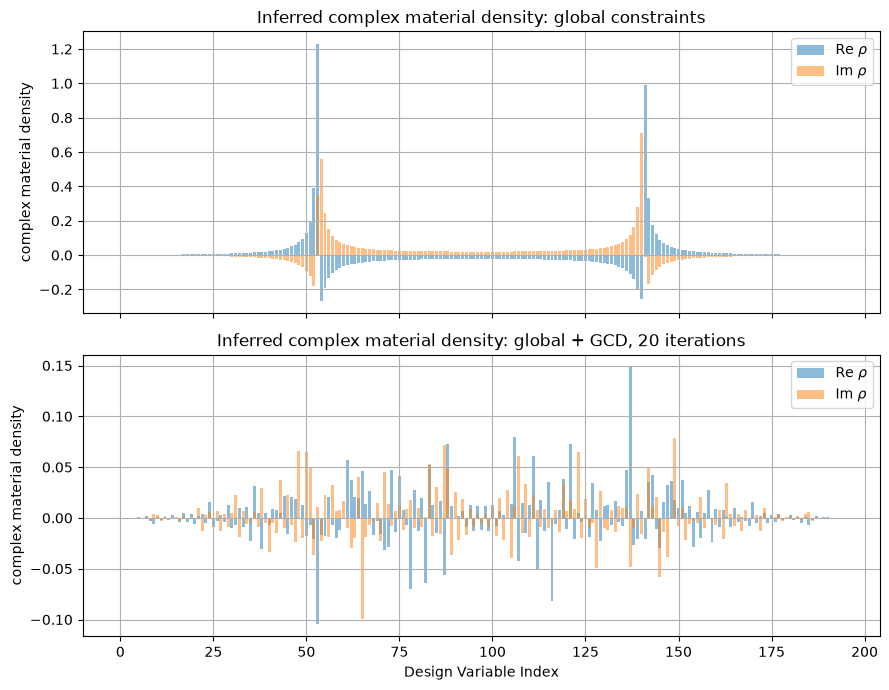

In [12]:
def complexDensity(Vsca):
    # inferred complex material density rho = 1 + Zs dI / E (Cholesky space)
    return 1 + Zs*dIfromV(Vsca)/(Eb + Vsca)

rhoGlob = complexDensity(QCQP.current_xstar)    # global constraints
rhoLoc = complexDensity(gQCQP.current_xstar)    # after Ngcd GCD iterations
cases = [("global constraints", rhoGlob), (f"global + GCD, {Ngcd} iterations", rhoLoc)]
for name, rho in cases:
    print(f"{name}: Re rho in [{rho.real.min():.3f}, {rho.real.max():.3f}], "
          f"Im rho in [{rho.imag.min():.3f}, {rho.imag.max():.3f}], ||Im rho||/||rho|| {np.linalg.norm(rho.imag)/np.linalg.norm(rho):.3e}")

fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)
for ax, (name, rho) in zip(axes, cases):
    ax.bar(np.arange(Ndes), np.real(rho), alpha=0.5, label=r'Re $\rho$')
    ax.bar(np.arange(Ndes), np.imag(rho), alpha=0.5, label=r'Im $\rho$')
    ax.set_ylabel('complex material density'); ax.set_title(f'Inferred complex material density: {name}')
    ax.legend(); ax.grid(True)
axes[-1].set_xlabel('Design Variable Index')
plt.tight_layout(); plt.show()

## Inference optimization over the material density $\rho$

As in `VscatBound.ipynb`, $\rho \in [0,1]^N$ is fitted from $I_i = \rho_i Z_\mathrm{s}^{-1} E_i$, now with
$E = E_\mathrm{b} + V_\mathrm{sca}$ and $I = I_\mathrm{full} - Z_0^{-1} V_\mathrm{sca}$. In the background picture this is the fit of the
removed fraction $1 - \rho_i$ from $\Delta I_i = -(1-\rho_i) Z_\mathrm{s}^{-1} E_i$, the same problem.

In [13]:
def fitDensity(Vsca):
    # argmin_{rho in [0,1]^N} || rho E/Zs - I ||, separable: projection of the pointwise least squares solution
    b = (Eb + Vsca)/Zs
    I = VtoI(Vsca)
    rho = np.clip(np.real(np.conj(b)*I)/np.abs(b)**2, 0, 1)
    res = np.linalg.norm(rho*b - I)/np.linalg.norm(I)
    return rho, res

def realizedObj(rho):
    # radiated power of the structure with density rho: (Zs + diag(rho) Z0) I = diag(rho) V
    S = np.diag(rho.astype(complex))
    I = np.linalg.solve(Zs*np.eye(Ndes) + S @ Z0, S @ Vinc)
    return evalObjI(I)

rhoFull, resFull = fitDensity(np.zeros(Ndes, dtype=complex))
print(f"full plate check: rho in [{rhoFull.min():.6f}, {rhoFull.max():.6f}], relative fit residual {resFull:.2e}")

ths = np.linspace(0.05, 0.95, 19)
fits = {}
print(f"dual bound: global {QCQP.current_dual:.6e} W, GCD {gQCQP.current_dual:.6e} W, full plate {Pfull:.6e} W")
for name, Vs in [("global constraints", QCQP.current_xstar), (f"global + GCD, {Ngcd} iterations", gQCQP.current_xstar)]:
    rho, res = fitDensity(Vs)
    Pbin = np.array([realizedObj((rho > t).astype(float)) for t in ths])
    fits[name] = (rho, Pbin)
    print(f"{name}: relative fit residual {res:.3e}, mean density {rho.mean():.3f}, "
          f"realized objective {realizedObj(rho):.6e} W, best binary {Pbin.max():.6e} W (threshold {ths[np.argmax(Pbin)]:.2f})")

full plate check: rho in [1.000000, 1.000000], relative fit residual 1.72e-12
dual bound: global 1.012093e+01 W, GCD 1.010927e+01 W, full plate 1.010821e+01 W
global constraints: relative fit residual 9.086e-01, mean density 0.024, realized objective 9.511796e-04 W, best binary 4.415367e-08 W (threshold 0.05)
global + GCD, 20 iterations: relative fit residual 8.454e-01, mean density 0.009, realized objective 4.425594e-07 W, best binary 2.398600e-10 W (threshold 0.05)


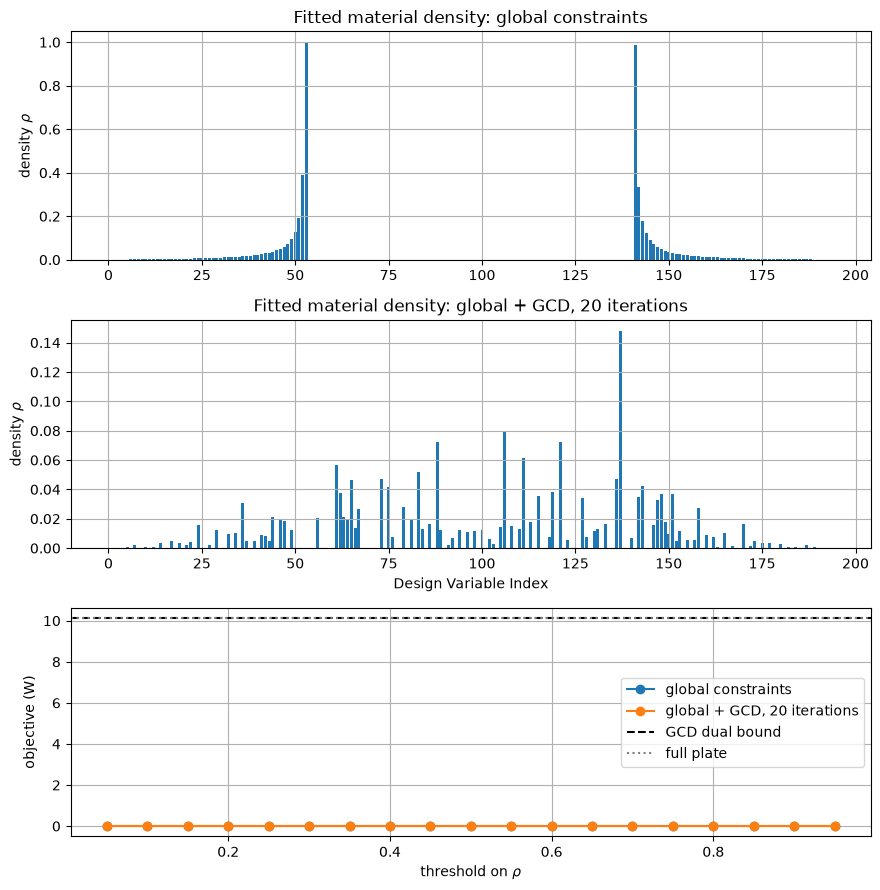

In [14]:
fig, axes = plt.subplots(3, 1, figsize=(9, 9))
for ax, (name, (rho, _)) in zip(axes[:2], fits.items()):
    ax.bar(np.arange(Ndes), rho)
    ax.set_ylabel(r'density $\rho$'); ax.set_title(f'Fitted material density: {name}'); ax.grid(True)
axes[1].set_xlabel('Design Variable Index')
for name, (_, Pbin) in fits.items():
    axes[2].plot(ths, Pbin, 'o-', label=name)
axes[2].axhline(gQCQP.current_dual, ls='--', c='k', label='GCD dual bound')
axes[2].axhline(Pfull, ls=':', c='gray', label='full plate')
axes[2].set_xlabel(r'threshold on $\rho$'); axes[2].set_ylabel('objective (W)'); axes[2].legend(); axes[2].grid(True)
plt.tight_layout(); plt.show()